# Is research-topic churn real or small-sample noise?

**Demo of `method.py`: the orchestrator and output stage of the thin-sample confound check.**

Earlier experiments found that a concept's *home-neighbourhood churn/novelty* (how much its partner topics turn over, and how novel they are, in its early years) predicts how broadly the concept later spreads across disciplines (outcome `O2r_m50`). This experiment asks whether that signal is **real** or a **by-product of thin samples**: concepts with ~10 papers per year will show "churn" just from sampling noise.

The full pipeline (stages `s0_gate.py` … `s8_power.py`) computes raw indicators and several noise-controlled variants for 13,444 concepts:

| variant family | what it controls for |
|---|---|
| `*_raw`, `NOVCHURN_raw`, `OPEN_home` | nothing (original EXP10 indicators) |
| V1 `*_rare5`, `*_rare10` | fixed-n rarefaction (n papers per year) |
| V2 `*_exc`, `*_nullmean`; V2b `EP_chao` | within-concept year-permutation null; Chao-corrected Jaccard |
| V3 `z_dens_cfg`, `z_pers_cfg`, `NOVCHURN_cfg`, `OPEN_home_clean` | degree-preserving configuration nulls |
| V4 | split-half reliability |

`method.py` then (i) optionally runs every stage (`--run-all`) and (ii) always runs **`build_outputs()`**. That function:
1. standardises the B5 baseline covariates with the frozen EXP10 constants,
2. fits OLS predictors of `O2r_m50` **on the DEV body only**: B5 alone and B5 + each churn variant,
3. checks out-of-DEV Spearman on the held-out bodies (OLDHO, COH1014, COH1517),
4. writes `method_out.json`, with one example per concept plus a metadata block summarising the verdict.

This notebook runs step (ii) **with the original code**, on a curated 100-concept subset (`mini_demo_data.json`). The stage scripts need the multi-GB OpenAlex cache, so their *aggregate results* are loaded from the same JSON: frozen spec, verdict, headline partial Spearman, reliability, size dependence and power.

> Label: selection data, outcomes previously unsealed. These results are robustness evidence, not confirmation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
This is the original import block of `method.py`. `argparse`, `subprocess` and `sys` are only needed by the CLI and stage runner. The `sys.path` insert and `from common import ...` are replaced further down by small in-notebook equivalents. `matplotlib` is added for the final visualisation.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt  # added for the demo visualisation

## Data loading
`mini_demo_data.json` is fetched from the GitHub repo, with a fallback to a local copy. It holds one dataset, `selection_concepts_table`: 100 concepts (34 DEV + 22 each of OLDHO / COH1014 / COH1517), spread across the outcome range. Each row has every column `build_outputs()` reads. The file's `metadata` also holds the result-JSON fragments the function reads.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_ud-q6jnkjLXa/round-5/experiment-16/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("demo rows:", len(data["datasets"][0]["examples"]), "| full analysis table:", data["metadata"]["n_full_table"], "concepts")

Curated 100-concept subset of the experiment-16 analysis table (POOLED, finite O2r_m50) plus the result-JSON fragments read by method.py:build_outputs(). Selection data, outcomes previously unsealed: robustness evidence, not confirmation.
demo rows: 100 | full analysis table: 7748 concepts


## Config
The original `build_outputs()` has no iteration counts. Its only size knob is how many concepts enter the table: all 7,748 with a finite outcome in the full run. The one hard-coded threshold is the minimum body size for reporting an out-of-DEV Spearman (`ok.sum() > 20`).

* `MAX_PER_BODY`: concepts kept per body from the demo table (the demo file has at most 34 DEV / 22 per other body). A value of at least 21 is needed for a held-out body to pass the `> 20` rule.
* `MIN_N_SPEARMAN`: the original threshold, 20.

In [5]:
MAX_PER_BODY = 34      # demo: all 100 rows (34 DEV + 22 x 3). Original full run: no cap (7,748 concepts; DEV 2,7xx)
MIN_N_SPEARMAN = 20    # original hard-coded value in build_outputs(): `ok.sum() > 20`

## Constants (verbatim from `method.py`)
* `STAGES`: the pipeline stage scripts and the output file each produces. It is used only by `run_stages()`, which is shown for reference below.
* `B5`: the five baseline covariates: log volume, growth, off-home share, entropy, reach.
* `PRED_X`: the prediction models. Each is B5 alone or B5 plus one churn variant.
* `INPUT_COLS`: the raw and noise-controlled indicator columns copied into every output example.

In [6]:
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
PRED_X = {"B5": None, "B5_plus_NOVCHURN_raw": "NOVCHURN_raw", "B5_plus_NOVCHURN_exc": "NOVCHURN_exc",
          "B5_plus_NOVCHURN_cfg": "NOVCHURN_cfg", "B5_plus_OPEN_home": "OPEN_home",
          "B5_plus_OPEN_home_clean": "OPEN_home_clean"}
INPUT_COLS = ["NOV_res__raw", "edge_persistence__raw", "ego_density_W3__raw", "new_edge_rate__raw", "n_comm_W3__raw",
              "participation__raw", "NOVCHURN_raw", "OPEN_home", "NOV_res_rare10", "edge_persistence_rare10",
              "NOVCHURN_rare10", "NOV_res_rare5", "edge_persistence_rare5", "NOVCHURN_rare5", "NOV_res_exc",
              "edge_persistence_exc", "edge_persistence_nullmean", "NOVCHURN_exc", "EP_chao", "NOVCHURN_chao",
              "z_dens_cfg", "z_dens_k", "z_pers_cfg", "excess_pers_cfg", "NOVCHURN_cfg", "OPEN_home_clean",
              "OPEN_home_exc"]

## Helpers replacing `lib/common.py` and `lib/tables.py`
The original imports `ROOT`, `RES`, `jdump` and `setup_logger` from `lib/common.py`, and `load_tables` from `lib/tables.py`. The original `load_tables()` joins `data/clean_variants.parquet` with the EXP10 covariate/outcome frames. Here it returns the same POOLED table, built from the demo rows (capped at `MAX_PER_BODY` per body). `jdump` and `_clean` are copied verbatim. The result files that the original reads from `results/*.json` come from `data["metadata"]`.

In [7]:
ROOT = Path(".")
RES = ROOT / "results"
RES.mkdir(exist_ok=True)


def _clean(o):  # verbatim from lib/common.py
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    return o


def jdump(obj, path: Path) -> None:  # verbatim from lib/common.py
    Path(path).write_text(json.dumps(_clean(obj), indent=1, default=str))


def load_tables() -> dict[str, pd.DataFrame]:
    """Demo stand-in for lib/tables.load_tables(): POOLED table from mini_demo_data.json (None -> NaN)."""
    df = pd.DataFrame(data["datasets"][0]["examples"])
    num = [c for c in df.columns if c not in ("concept_id", "name", "body", "agroup")]
    df[num] = df[num].astype(float)
    df = df.groupby("body", sort=False, group_keys=False).head(MAX_PER_BODY).reset_index(drop=True)
    return {"POOLED": df}


logger.remove()
_ = logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

### Stage runner and dependency cross-checks (reference only)
`run_stages()` runs the 14 stage scripts in order. `concept_key_check()` and `exp12_crosscheck()` read other artifacts' multi-GB files: the OpenAlex concept-recognition key and the EXP12 feature parquet. None of these can run in a notebook. Their bodies are kept as markdown and replaced by stubs that say they were not run.

```python
def run_stages(force: bool) -> None:
    for script, out in STAGES:
        if out.exists() and not force:
            logger.info(f"skip {script} ({out.name} exists)"); continue
        ...
        subprocess.run([sys.executable, str(ROOT / script)], check=True, cwd=ROOT)
```
In the full run, `concept_key_check()` found all analysed concepts in the recognition table, with the OpenAlex level agreeing. `exp12_crosscheck()` reported agreement with EXP12's home-build components (informational only).

In [8]:
def concept_key_check() -> dict:
    # needs art_O7Dq4L02QnDN full_data_out/*.json (not shipped with the demo)
    return {"available": False, "note": "not run in demo (needs dependency artifact files)"}


def exp12_crosscheck() -> dict:
    # needs EXP12 open_features.parquet (not shipped with the demo)
    return {"available": False}

## `build_outputs()` step 1: read the frozen spec and results, standardise B5
The code below is the body of `build_outputs()` split into cells. The four `json.loads(... .read_text())` calls now read the same objects from `data["metadata"]`. `pm` holds the **frozen EXP10** mean and sd of the B5 covariates. They were sealed before any outcome join, so standardisation cannot leak outcome information. `dev` marks the DEV-body rows with finite covariates. Only these rows are used for fitting.

In [9]:
M = data["metadata"]
spec = M["frozen_spec"]                   # was: json.loads((RES / "frozen_spec.json").read_text())
pm = spec["exp10_prediction_models"]["B5"]
V = M["clean_vs_raw_psp"]                 # was: json.loads((RES / "clean_vs_raw_psp.json").read_text())
rel = M["reliability"]                    # was: json.loads((RES / "reliability.json").read_text())
pw = M["power_frame_n"]                   # was: json.loads((RES / "power_frame_n.json").read_text())
sz = M["size_dependence"]                 # was: json.loads((RES / "size_dependence.json").read_text())
T = load_tables()["POOLED"]
T = T[np.isfinite(T.O2r_m50)].reset_index(drop=True)
Zb = np.column_stack([(T[c].to_numpy(float) - pm["mu"][c]) / pm["sd"][c] for c in B5])
dev = (T.body == "DEV").to_numpy() & np.all(np.isfinite(Zb), 1)
y = T.O2r_m50.to_numpy(float)
print(T.body.value_counts().to_dict(), "| DEV rows used for fitting:", int(dev.sum()))

{'DEV': 34, 'OLDHO': 22, 'COH1014': 22, 'COH1517': 22} | DEV rows used for fitting: 34


## Step 2: fit the DEV-only OLS prediction models
For each model in `PRED_X`, the design matrix is intercept + standardised B5, plus the churn variant if the model has one. A missing variant value (NaN, e.g. too few papers for rarefaction) is imputed with the **DEV median** and flagged in `imputed`. Coefficients come from least squares on DEV rows only, and predictions are made for every row.

In [10]:
preds, imputed, coefs = {}, {}, {}
for nm, x in PRED_X.items():
    X = Zb.copy()
    if x is not None:
        v = T[x].to_numpy(float)
        med = float(np.nanmedian(v[dev]))
        imputed[nm] = ~np.isfinite(v)
        v = np.where(np.isfinite(v), v, med)
        X = np.c_[X, v]
    A = np.c_[np.ones(len(T)), X]
    okf = dev & np.all(np.isfinite(A), 1)
    b = np.linalg.lstsq(A[okf], y[okf], rcond=None)[0]
    coefs[nm] = b.tolist()
    preds[nm] = A @ b
for nm, b in coefs.items():
    print(f"{nm:<26} intercept {b[0]:+.3f}   extra-variant coef {'' if len(b) == 6 else f'{b[-1]:+.3f}'}")

B5                         intercept +5.162   extra-variant coef 
B5_plus_NOVCHURN_raw       intercept +5.260   extra-variant coef +0.753
B5_plus_NOVCHURN_exc       intercept +5.171   extra-variant coef +0.476
B5_plus_NOVCHURN_cfg       intercept +5.134   extra-variant coef +0.694
B5_plus_OPEN_home          intercept +5.055   extra-variant coef +0.905
B5_plus_OPEN_home_clean    intercept +4.982   extra-variant coef +0.957


## Step 3: out-of-DEV check
For each held-out body, the code computes the Spearman correlation between each model's prediction and the observed outcome, then each variant model's **gain over B5**. The artifact expects this gain to be about 0: the churn variants add little *predictive* signal beyond B5, even when their partial correlations are nonzero. The only edit is that `20` is now `MIN_N_SPEARMAN`.

In [11]:
chk = {"note": "OLS fitted on DEV only; out-of-DEV Spearman with O2r_m50 (gain over B5 expected ~0)", "coef": coefs}
for body in ("OLDHO", "COH1014", "COH1517"):
    m = (T.body == body).to_numpy()
    ent = {}
    for nm, p in preds.items():
        ok = m & np.isfinite(p)
        ent[nm] = float(stats.spearmanr(p[ok], y[ok])[0]) if ok.sum() > MIN_N_SPEARMAN else None
    ent["n"] = int(m.sum())
    ent["gain_vs_B5"] = {nm: (ent[nm] - ent["B5"]) if ent[nm] is not None and ent["B5"] is not None else None
                         for nm in PRED_X if nm != "B5"}
    chk[body] = ent
jdump(chk, RES / "prediction_check.json")
print(json.dumps({b: {k: (round(v, 3) if isinstance(v, float) else v) for k, v in chk[b].items() if k != "gain_vs_B5"}
                  for b in ("OLDHO", "COH1014", "COH1517")}, indent=1))

{
 "OLDHO": {
  "B5": 0.8,
  "B5_plus_NOVCHURN_raw": 0.815,
  "B5_plus_NOVCHURN_exc": 0.756,
  "B5_plus_NOVCHURN_cfg": 0.799,
  "B5_plus_OPEN_home": 0.746,
  "B5_plus_OPEN_home_clean": 0.731,
  "n": 22
 },
 "COH1014": {
  "B5": 0.842,
  "B5_plus_NOVCHURN_raw": 0.869,
  "B5_plus_NOVCHURN_exc": 0.846,
  "B5_plus_NOVCHURN_cfg": 0.85,
  "B5_plus_OPEN_home": 0.853,
  "B5_plus_OPEN_home_clean": 0.855,
  "n": 22
 },
 "COH1517": {
  "B5": 0.774,
  "B5_plus_NOVCHURN_raw": 0.78,
  "B5_plus_NOVCHURN_exc": 0.797,
  "B5_plus_NOVCHURN_cfg": 0.753,
  "B5_plus_OPEN_home": 0.805,
  "B5_plus_OPEN_home_clean": 0.801,
  "n": 22
 }
}


## Step 4: build one output example per concept (`exp_gen_sol_out` format)
Each example carries:
* `input`: a JSON string with the concept id, name, body, `t0`, `n_home_early` and all `INPUT_COLS`,
* `output`: the observed `O2r_m50`,
* `predict_<model>`: each model's prediction,
* flags for imputed or missing clean variants.

In [12]:
exs = []
for i, r in T.iterrows():
    inp = {"concept_id": str(r.concept_id), "name": str(r["name"]), "body": r.body, "t0": int(r.t0),
           "n_home_early": int(r.n_home_early)}
    for c in INPUT_COLS:
        v = r[c]
        inp[c] = None if not np.isfinite(v) else round(float(v), 6)
    e = {"input": json.dumps(inp), "output": f"{r.O2r_m50:.6f}"}
    for nm, p in preds.items():
        e[f"predict_{nm}"] = f"{p[i]:.6f}" if np.isfinite(p[i]) else "nan"
    e["metadata_body"] = r.body
    e["metadata_agroup"] = r.agroup
    e["metadata_O2r_resid"] = None if not np.isfinite(r.O2r_resid) else float(r.O2r_resid)
    e["metadata_imputed_variants"] = [nm for nm in imputed if imputed[nm][i]]
    e["metadata_missing_clean_variants"] = [c for c in ("NOVCHURN_exc", "NOVCHURN_rare10", "NOVCHURN_cfg",
                                                        "OPEN_home_clean") if not np.isfinite(r[c])]
    exs.append(e)
print(len(exs), "examples; first one:")
print(json.dumps(exs[0], indent=1)[:1500])

100 examples; first one:
{
 "input": "{\"concept_id\": \"2778079797\", \"name\": \"Infratemporal fossa\", \"body\": \"DEV\", \"t0\": 2005, \"n_home_early\": 45, \"NOV_res__raw\": -0.91676, \"edge_persistence__raw\": 0.0, \"ego_density_W3__raw\": 0.785714, \"new_edge_rate__raw\": 0.074074, \"n_comm_W3__raw\": 1.0, \"participation__raw\": 0.0, \"NOVCHURN_raw\": -0.109903, \"OPEN_home\": -0.353592, \"NOV_res_rare10\": null, \"edge_persistence_rare10\": null, \"NOVCHURN_rare10\": null, \"NOV_res_rare5\": null, \"edge_persistence_rare5\": 0.0, \"NOVCHURN_rare5\": null, \"NOV_res_exc\": -0.0, \"edge_persistence_exc\": -0.127336, \"edge_persistence_nullmean\": 0.127336, \"NOVCHURN_exc\": 0.66314, \"EP_chao\": 0.697805, \"NOVCHURN_chao\": -1.164337, \"z_dens_cfg\": 22.585042, \"z_dens_k\": 19.355245, \"z_pers_cfg\": null, \"excess_pers_cfg\": 0.0, \"NOVCHURN_cfg\": null, \"OPEN_home_clean\": -0.815865, \"OPEN_home_exc\": -0.283132}",
 "output": "1.953198",
 "predict_B5": "3.167472",
 "predict_

## Step 5: metadata block and `method_out.json`
The metadata block summarises the whole pipeline:
* the mechanical **verdict** (`PARTLY_THIN`),
* whether predictions P1–P3 hold,
* the headline partial Spearman ρ of each variant with `O2r_m50` given B5 + R2, per body and pooled,
* pooled split-half (Spearman–Brown) reliabilities,
* the thin-sample share: R² of raw persistence on its own permutation-null mean,
* the power statement.

In [13]:
vd = V["verdict"]
head = {h["variant"]: {b: h[b].get("psp") for b in ("DEV", "OLDHO", "COH1014", "COH1517", "POOLED")}
        for h in V["headline_R2_O2r_m50"]}
meta = {"method_name": "Thin-sample confound check of home-only neighbourhood churn (raw vs noise-controlled "
                       "variants)",
        "label": "selection data, outcomes previously unsealed: robustness evidence, not confirmation",
        "verdict": vd["verdict"], "DEGREE_ARTEFACT_PERSISTENCE": vd["DEGREE_ARTEFACT_PERSISTENCE"],
        "predictions_P1_P3": {k: v["holds"] for k, v in V["predictions"].items()},
        "P_detail": V["predictions"], "headline_psp_R2_O2r_m50": head,
        "reliability_pooled_SB": {k: v["pooled"]["SB"] for k, v in rel["variants"].items()},
        "outcome_reliability_SB": rel["outcome"]["O2r_m50"]["pooled"]["SB"],
        "thin_sample_share_R2": sz["thin_sample_share"]["POOLED"]["R2"],
        "power_plain_language": pw["plain_language"],
        "concept_key_check": concept_key_check(), "exp12_home_crosscheck": exp12_crosscheck(),
        "n_examples": len(exs), "prediction_models": "OLS on DEV (B5 standardised with EXP10 frozen mu/sd); "
                                                     "NaN variants imputed with the DEV median (flagged)"}
out = {"metadata": meta, "datasets": [{"dataset": "selection_concepts", "examples": exs}]}
(ROOT / "method_out.json").write_text(json.dumps(out, indent=1, default=lambda o: None if isinstance(o, float)
                                                 and not math.isfinite(o) else str(o)))
logger.info(f"method_out.json: {len(exs)} examples; verdict {vd['verdict']}")

02:26:59|INFO   |method_out.json: 100 examples; verdict PARTLY_THIN


## Results
Three views follow:
1. **Verdict and predictions.**
2. **Headline partial Spearman (pooled, full run of 6k+ concepts).** Raw churn vs its noise-controlled variants. The V2 permutation-excess variants (`*_exc`) collapse to about 0. Fixed-n rarefaction (`rare10`), Chao and configuration-null variants keep most of the signal. So the association reflects a *static* dispersion of the home topic mix, not temporal partner turnover.
3. **Demo re-run of `build_outputs()`.** Out-of-DEV Spearman of each model's prediction on this 100-concept subset, next to the full-run values, plus a scatter of predictions against outcomes. With only 22 held-out concepts per body, the demo numbers are noisy. Read them as a working demonstration of the code, not a replication.

VERDICT: PARTLY_THIN   DEGREE_ARTEFACT_PERSISTENCE: False
  P1: FAILS
  P2: holds
  P3: holds
thin-sample share R2 (raw persistence ~ its V2 null mean): 0.66
outcome reliability SB: 0.895
power: At n = 800 (S_A, T3 = half the pooled raw estimate) joint power (OPEN_home R3 & R5 & NOVCHURN_raw R3) = 0.07; at n = 2500 it is 0.26. With T2 (COH1517 raw) it is 0.31 / 0.75. Pessimistic n-mix (S_B, T ...

Headline partial Spearman with O2r_m50 | B5 + R2 (full run):
                             DEV  OLDHO  COH1014  COH1517  POOLED  SB_pooled
NOVCHURN_raw               0.116  0.113    0.113    0.161   0.116      0.476
NOVCHURN_exc               0.008  0.006   -0.007    0.063   0.008      0.014
NOVCHURN_zperm             0.007  0.021   -0.003    0.073   0.012      0.023
NOVCHURN_rare5             0.127  0.140    0.149    0.105   0.130      0.359
NOVCHURN_rare10            0.066  0.044    0.076    0.176   0.078        NaN
NOVCHURN_cfg               0.115  0.071    0.114    0.088   0.106      0.618

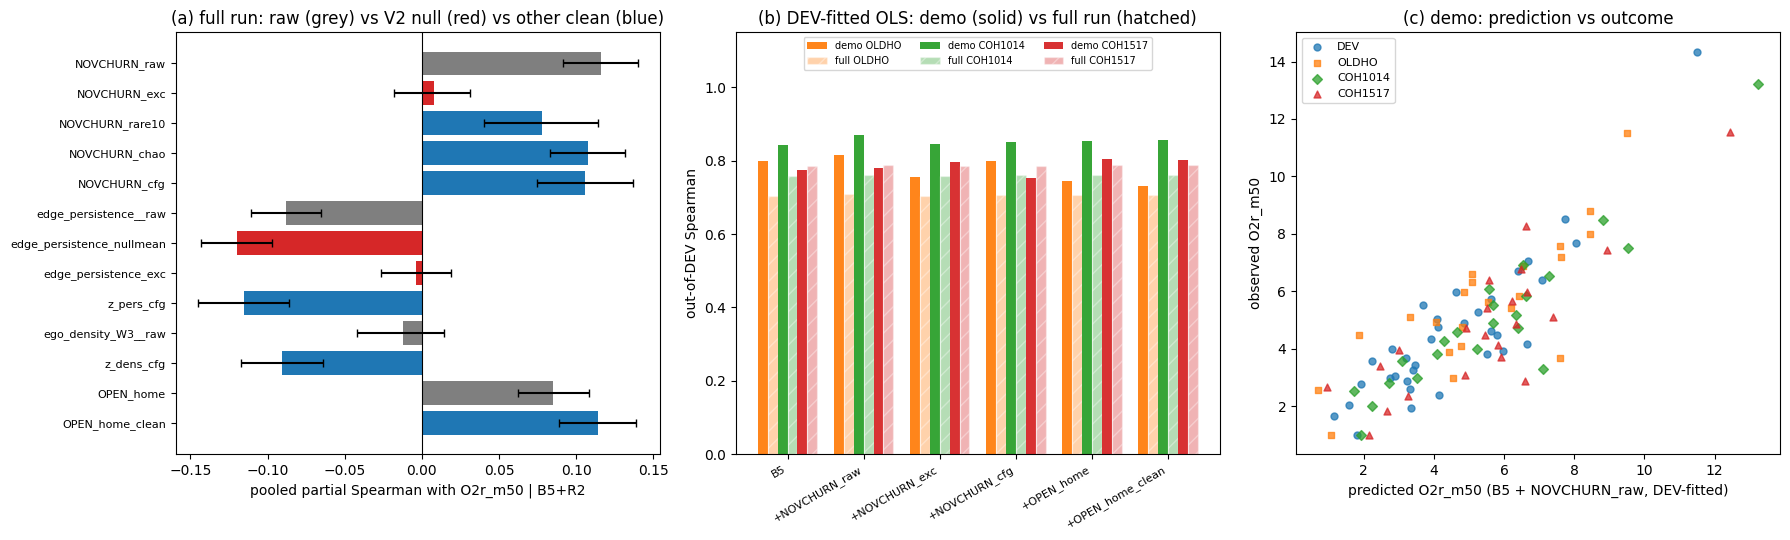

In [14]:
print(f"VERDICT: {meta['verdict']}   DEGREE_ARTEFACT_PERSISTENCE: {meta['DEGREE_ARTEFACT_PERSISTENCE']}")
for k, v in V["predictions"].items():
    print(f"  {k}: {'holds' if v['holds'] else 'FAILS'}")
print(f"thin-sample share R2 (raw persistence ~ its V2 null mean): {meta['thin_sample_share_R2']:.2f}")
print(f"outcome reliability SB: {meta['outcome_reliability_SB']:.3f}")
print("power:", meta["power_plain_language"][:200], "...")

# --- headline table (full run) ---
hd = pd.DataFrame(head).T[["DEV", "OLDHO", "COH1014", "COH1517", "POOLED"]]
sb = pd.Series(meta["reliability_pooled_SB"], name="SB_pooled")
hd = hd.join(sb, how="left")
print("\nHeadline partial Spearman with O2r_m50 | B5 + R2 (full run):")
print(hd.round(3).to_string())

# --- demo vs full-run out-of-DEV Spearman ---
full_pc = M["full_run_prediction_check"]
rows = []
for body in ("OLDHO", "COH1014", "COH1517"):
    for nm in PRED_X:
        rows.append({"body": body, "model": nm, "demo_rho": chk[body][nm], "full_rho": full_pc[body][nm]})
cmp = pd.DataFrame(rows).pivot(index="model", columns="body", values=["demo_rho", "full_rho"])
print("\nOut-of-DEV Spearman(prediction, O2r_m50): demo subset vs full run")
print(cmp.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
# (a) headline pooled psp with CIs
H = {h["variant"]: h["POOLED"] for h in V["headline_R2_O2r_m50"]}
order = [v for v in ["NOVCHURN_raw", "NOVCHURN_exc", "NOVCHURN_rare10", "NOVCHURN_chao", "NOVCHURN_cfg",
                     "edge_persistence__raw", "edge_persistence_nullmean", "edge_persistence_exc", "z_pers_cfg",
                     "ego_density_W3__raw", "z_dens_cfg", "OPEN_home", "OPEN_home_clean"] if v in H]
ps = np.array([H[v]["psp"] for v in order])
ci = np.array([H[v].get("ci") or [np.nan, np.nan] for v in order], dtype=float)
col = ["tab:gray" if ("raw" in v or v == "OPEN_home") else ("tab:red" if ("exc" in v or "nullmean" in v) else "tab:blue")
       for v in order]
ax = axes[0]
ax.barh(range(len(order)), ps, color=col, xerr=np.abs(np.vstack([ps - ci[:, 0], ci[:, 1] - ps])), capsize=3)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8); ax.invert_yaxis(); ax.axvline(0, c="k", lw=.8)
ax.set_xlabel("pooled partial Spearman with O2r_m50 | B5+R2"); ax.set_title("(a) full run: raw (grey) vs V2 null (red) vs other clean (blue)")
# (b) demo vs full out-of-DEV rho
ax = axes[1]
models = list(PRED_X); xs = np.arange(len(models)); w = 0.13
for j, (body, cc) in enumerate(zip(("OLDHO", "COH1014", "COH1517"), ("tab:orange", "tab:green", "tab:red"))):
    ax.bar(xs + (2 * j - 2.5) * w, [chk[body][m] if chk[body][m] is not None else np.nan for m in models], w,
           label=f"demo {body}", color=cc, alpha=.95)
    ax.bar(xs + (2 * j - 1.5) * w, [full_pc[body][m] for m in models], w, label=f"full {body}", color=cc, alpha=.35,
           hatch="//", edgecolor="white")
ax.set_xticks(xs); ax.set_xticklabels([m.replace("B5_plus_", "+") for m in models], rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("out-of-DEV Spearman"); ax.set_title("(b) DEV-fitted OLS: demo (solid) vs full run (hatched)")
ax.legend(fontsize=7, ncol=3, loc="upper center")
# (c) scatter predictions vs outcome
ax = axes[2]
for body, mk in zip(("DEV", "OLDHO", "COH1014", "COH1517"), "osD^"):
    m = (T.body == body).to_numpy()
    ax.scatter(preds["B5_plus_NOVCHURN_raw"][m], y[m], marker=mk, s=25, alpha=.75, label=body)
ax.set_xlabel("predicted O2r_m50 (B5 + NOVCHURN_raw, DEV-fitted)"); ax.set_ylabel("observed O2r_m50")
ax.set_title("(c) demo: prediction vs outcome"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()